# C3 Revision — Distribution-Shift Robustness

## Scientific question

Does the frozen C2 model configuration retain its empirical competitiveness when the evaluation distribution departs from the stationary test distribution?

## Frozen from C2

- 10 training runs
- 1000 training samples per run
- n = 4
- reps = 2
- quantum C = 3.0
- all classical hyperparameters loaded from `c2_downstream_tuned_parameters.json`

C3 changes only the evaluation distribution. No hyperparameter tuning is performed.


## 1. Load frozen C2 contract


In [1]:
import hashlib
import json
import os
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import binomtest, t, wilcoxon
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(exc)

from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel


def find_project_root(start=None):
    """Tìm root repo bằng config.py để notebook chạy được từ nhiều cwd."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy config.py trong cwd hoặc parent directories.")


def file_sha256(path):
    """Tính SHA256 cho artifact để cache tự invalid khi artifact C1 đổi."""
    digest = hashlib.sha256()
    with open(path, "rb") as fp:
        for chunk in iter(lambda: fp.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


ROOT_DIR = find_project_root()
os.chdir(ROOT_DIR)

from config import (  # noqa: E402
    LABEL_COLS,
    NSLKDD_MODELS_DIR,
    NSLKDD_PROCESSED_DIR,
    NSLKDD_RESULTS_DIR,
)

OUTPUT_DIR = NSLKDD_RESULTS_DIR / "c3_revision"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
SUBSET_DIR = OUTPUT_DIR / "eval_subsets"
for path in [OUTPUT_DIR, FIGURE_DIR, CACHE_DIR, SUBSET_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Phase C mặc định: chạy pilot run 1 trước. Đổi False để chạy full 10-run C3.
PILOT_MODE = False
FORCE_RERUN = False
RUN_IDS = list(range(1, 11))
RUN_SEEDS = list(range(100, 110))
RUN_IDS_TO_EXECUTE = [1] if PILOT_MODE else RUN_IDS

C1_ARTIFACT_PATHS = {
    "feature_selector": NSLKDD_MODELS_DIR / "feature_selector_k20.joblib",
    "pca": NSLKDD_MODELS_DIR / "pca_4components.joblib",
    "angle_scaler": NSLKDD_MODELS_DIR / "scaler_minmax_pi.joblib",
}
C1_ARTIFACT_HASHES = {
    name: file_sha256(path)
    for name, path in C1_ARTIFACT_PATHS.items()
}

ALL_MODELS = [
    "QSVM_ZZ",
    "QSVM_Z",
    "SVM_Linear",
    "SVM_Poly2",
    "SVM_RBF",
    "RandomForest",
    "XGBoost",
]
ALL_BASELINES = [model for model in ALL_MODELS if model != "QSVM_ZZ"]
EXPECTED_MODELS = set(ALL_MODELS)
INFERENTIAL_FAMILIES = {
    "entanglement": ["QSVM_Z"],
    "strong_tabular": ["RandomForest", "XGBoost"],
    "classical_kernel": ["SVM_RBF", "SVM_Poly2", "SVM_Linear"],
}
BASELINE_FAMILY_BY_MODEL = {
    model: family
    for family, models in INFERENTIAL_FAMILIES.items()
    for model in models
}

C3_CONFIG = {
    "selected_n": 4,
    "select_k": 20,
    "reps": 2,
    "entanglement": "full",
    "n_runs": 10,
    "train_size": 1000,
    "eval_size": 1000,
    "eval_min_rare": 30,
    "rare_categories": ["U2R", "R2L"],
    "run_ids": RUN_IDS,
    "run_seeds": RUN_SEEDS,
    "run_ids_to_execute": RUN_IDS_TO_EXECUTE,
    "pilot_mode": PILOT_MODE,
    "force_rerun": FORCE_RERUN,
    "sigma_levels": [0.0, 0.01, 0.05, 0.10, 0.20],
    "prior_attack_fractions": [0.30, 0.50, 0.70],
    "temporal_sources": {
        "KDDTestPlus": str(NSLKDD_PROCESSED_DIR / "NSL_KDD_Test_Cleaned.csv"),
        "KDDTest21": str(NSLKDD_PROCESSED_DIR / "NSL_KDD_Test21_Cleaned.csv"),
    },
    "c1_selection_path": str(NSLKDD_PROCESSED_DIR / "c1_selection.json"),
    "c1_artifacts": {name: str(path) for name, path in C1_ARTIFACT_PATHS.items()},
    "c1_artifact_hashes": C1_ARTIFACT_HASHES,
    "c2_contract_path": str(NSLKDD_RESULTS_DIR / "c2_revision" / "c2_downstream_tuned_parameters.json"),
    "c2_config_path": str(NSLKDD_RESULTS_DIR / "c2_revision" / "c2_config.json"),
    "quantum_backend": "FidelityStatevectorKernel_statevector_precomputed_SVC",
    "preprocessing_protocol": "frozen_C1_SelectKBest_PCA4_MinMaxPi_transform_only",
    "all_models": ALL_MODELS,
    "all_baselines": ALL_BASELINES,
    "inferential_families": INFERENTIAL_FAMILIES,
    "multiple_testing_policy": "All QSVM_ZZ-vs-baseline comparisons are reported; Holm correction is applied within predefined baseline families for each stress experiment/metric.",
    "statistics_unit": "run",
}

with open(C3_CONFIG["c2_config_path"], "r", encoding="utf-8") as fp:
    C2_CONFIG = json.load(fp)
with open(C3_CONFIG["c2_contract_path"], "r", encoding="utf-8") as fp:
    C2_DOWNSTREAM_TUNED_PARAMETERS = json.load(fp)
with open(C3_CONFIG["c1_selection_path"], "r", encoding="utf-8") as fp:
    C1_SELECTION = json.load(fp)

FROZEN_C1_TRANSFORMERS = {
    "selector": joblib.load(C1_ARTIFACT_PATHS["feature_selector"]),
    "pca": joblib.load(C1_ARTIFACT_PATHS["pca"]),
    "angle_scaler": joblib.load(C1_ARTIFACT_PATHS["angle_scaler"]),
}

hp = C2_DOWNSTREAM_TUNED_PARAMETERS
FROZEN_HYPERPARAMETERS = {
    model: payload["chosen_params"]
    for model, payload in hp["models"].items()
}

assert C2_CONFIG["n_runs"] == 10
assert C2_CONFIG["run_size"] == 1000
assert C3_CONFIG["eval_size"] == 1000
assert int(C1_SELECTION["selected_n"]) == C3_CONFIG["selected_n"]
assert int(FROZEN_C1_TRANSFORMERS["selector"].k) == C3_CONFIG["select_k"]
assert int(FROZEN_C1_TRANSFORMERS["pca"].n_components_) == C3_CONFIG["selected_n"]
assert tuple(FROZEN_C1_TRANSFORMERS["angle_scaler"].feature_range) == (0.0, np.pi)
assert hp["models"]["QSVM_ZZ"]["chosen_params"]["C"] == 3.0
assert hp["models"]["QSVM_ZZ"]["chosen_params"]["feature_map"] == "ZZFeatureMap"
assert hp["models"]["QSVM_ZZ"]["chosen_params"]["reps"] == C3_CONFIG["reps"]
assert hp["models"]["QSVM_ZZ"]["chosen_params"]["entanglement"] == C3_CONFIG["entanglement"]
assert hp["models"]["QSVM_Z"]["chosen_params"]["C"] == 3.0
assert hp["models"]["QSVM_Z"]["chosen_params"]["feature_map"] == "ZFeatureMap"
assert hp["models"]["QSVM_Z"]["chosen_params"]["reps"] == C3_CONFIG["reps"]
for model, payload in hp["models"].items():
    assert "chosen_params" in payload
    assert "best_mean_params" in payload
assert EXPECTED_MODELS.issubset(set(hp["models"]))
assert XGBOOST_AVAILABLE, f"XGBoost baseline is required for full C3: {globals().get('XGBOOST_IMPORT_ERROR', 'not available')}"
assert not FROZEN_HYPERPARAMETERS["XGBoost"].get("skipped", False)
assert set(BASELINE_FAMILY_BY_MODEL) == set(ALL_BASELINES)

signature_payload = {
    "config": {k: v for k, v in C3_CONFIG.items() if k not in ["pilot_mode", "run_ids_to_execute", "force_rerun"]},
    "frozen_hyperparameters": FROZEN_HYPERPARAMETERS,
}
CONFIG_SIGNATURE = hashlib.sha256(
    json.dumps(signature_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16]
C3_CONFIG["config_signature"] = CONFIG_SIGNATURE

with open(OUTPUT_DIR / "c3_config.json", "w", encoding="utf-8") as fp:
    json.dump(C3_CONFIG, fp, indent=2, ensure_ascii=False)
with open(OUTPUT_DIR / "c3_frozen_hyperparameters.json", "w", encoding="utf-8") as fp:
    json.dump(C2_DOWNSTREAM_TUNED_PARAMETERS, fp, indent=2, ensure_ascii=False)

print("C3 frozen configuration: PASS")
print(f"ROOT_DIR        : {ROOT_DIR}")
print(f"OUTPUT_DIR      : {OUTPUT_DIR}")
print(f"PILOT_MODE      : {PILOT_MODE}")
print(f"RUN_IDS_EXECUTE : {RUN_IDS_TO_EXECUTE}")
print(f"Config signature: {CONFIG_SIGNATURE}")
print("\nFrozen C1 representation artifacts:")
for name, path in C1_ARTIFACT_PATHS.items():
    print(f"  {name:<16}: {path.name}  sha256={C1_ARTIFACT_HASHES[name][:12]}...")
print("\nDownstream uses chosen_params only. best_mean_params are retained for provenance/audit.\n")
print(json.dumps(FROZEN_HYPERPARAMETERS, indent=2, ensure_ascii=False))


C3 frozen configuration: PASS
ROOT_DIR        : D:\coding\Research\Quantum\SVM
OUTPUT_DIR      : D:\coding\Research\Quantum\SVM\results\nslkdd\c3_revision
PILOT_MODE      : False
RUN_IDS_EXECUTE : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Config signature: 82fd00a51dab5ebf

Frozen C1 representation artifacts:
  feature_selector: feature_selector_k20.joblib  sha256=e072f5fc3be2...
  pca             : pca_4components.joblib  sha256=1a31c2fb2639...
  angle_scaler    : scaler_minmax_pi.joblib  sha256=f4a5090ba9f0...

Downstream uses chosen_params only. best_mean_params are retained for provenance/audit.

{
  "QSVM_ZZ": {
    "C": 3.0,
    "feature_map": "ZZFeatureMap",
    "reps": 2,
    "entanglement": "full"
  },
  "QSVM_Z": {
    "C": 3.0,
    "feature_map": "ZFeatureMap",
    "reps": 2
  },
  "SVM_Linear": {
    "svc__C": 0.1
  },
  "SVM_Poly2": {
    "svc__C": 0.1
  },
  "SVM_RBF": {
    "svc__C": 5.0
  },
  "RandomForest": {
    "max_depth": null,
    "min_samples_leaf": 1,
    "n_estimators":

## 2. Load 10 × 1000 training runs


In [2]:
multi_run_dir = NSLKDD_PROCESSED_DIR / "multi_run"
train_runs = {
    run_id: pd.read_csv(multi_run_dir / f"train_run{run_id}.csv")
    for run_id in RUN_IDS
}

assert len(train_runs) == 10
assert all(len(df) == C3_CONFIG["train_size"] for df in train_runs.values())

feature_cols = [c for c in train_runs[1].columns if c not in LABEL_COLS]
assert all(feature_cols == [c for c in df.columns if c not in LABEL_COLS] for df in train_runs.values())
assert all(set(LABEL_COLS).issubset(df.columns) for df in train_runs.values())

print(f"Loaded {len(train_runs)} training runs x {C3_CONFIG['train_size']} samples.")
print(f"Feature columns: {len(feature_cols)}")


Loaded 10 training runs x 1000 samples.
Feature columns: 122


## 3. Sampling helpers and evaluation subset generation


In [3]:
def _allocate_exact_counts(categories, counts, total, ensure_min_one=True):
    """Phân bổ exact-size theo largest remainder, giống logic preprocess."""
    categories = list(categories)
    counts = pd.Series(counts, index=categories, dtype=float).fillna(0)
    targets = pd.Series(0, index=categories, dtype=int)

    if total <= 0 or len(categories) == 0:
        return {cat: int(targets.loc[cat]) for cat in categories}

    positive = counts[counts > 0]
    if positive.empty:
        return {cat: int(targets.loc[cat]) for cat in categories}

    cats = list(positive.index)
    total = int(total)
    if ensure_min_one and total >= len(cats):
        targets.loc[cats] = 1
        remaining = total - len(cats)
    else:
        remaining = total

    if remaining > 0:
        weights = positive / positive.sum()
        raw = weights * remaining
        floors = np.floor(raw).astype(int)
        targets.loc[cats] += floors

        deficit = total - int(targets.sum())
        if deficit > 0:
            remainders = (raw - floors).sort_values(ascending=False)
            for cat in remainders.index[:deficit]:
                targets.loc[cat] += 1

    return {cat: int(targets.loc[cat]) for cat in categories}


def stratified_sample_for_qsvm(
    df,
    n_samples=1000,
    min_rare=30,
    rare_categories=("U2R", "R2L"),
    random_state=42,
):
    """Lấy mẫu theo attack_category, ưu tiên rare U2R/R2L như notebook preprocess."""
    if n_samples <= 0:
        raise ValueError("n_samples must be positive")
    if len(df) == 0:
        raise ValueError("Cannot sample from an empty DataFrame")

    rng = np.random.RandomState(random_state)
    sampled = []

    all_cats = list(df["attack_category"].dropna().unique())
    rare_cats = [c for c in rare_categories if c in all_cats]
    other_cats = [c for c in all_cats if c not in rare_cats]

    rare_targets = {}
    if rare_cats:
        rare_budget = min(n_samples, int(min_rare) * len(rare_cats))
        rare_counts = df["attack_category"].value_counts().reindex(rare_cats).fillna(0)
        rare_targets = _allocate_exact_counts(
            rare_cats,
            rare_counts,
            rare_budget,
            ensure_min_one=True,
        )

    used = 0
    for cat, n_take in rare_targets.items():
        if n_take <= 0:
            continue
        pool = df[df["attack_category"] == cat]
        replace = len(pool) < n_take
        part = pool.sample(n=n_take, replace=replace, random_state=rng.randint(1_000_000))
        sampled.append(part)
        used += n_take

    remaining = n_samples - used
    if remaining > 0 and other_cats:
        other_counts = df["attack_category"].value_counts().reindex(other_cats).fillna(0)
        other_targets = _allocate_exact_counts(
            other_cats,
            other_counts,
            remaining,
            ensure_min_one=True,
        )
        for cat, n_take in other_targets.items():
            if n_take <= 0:
                continue
            pool = df[df["attack_category"] == cat]
            replace = len(pool) < n_take
            part = pool.sample(n=n_take, replace=replace, random_state=rng.randint(1_000_000))
            sampled.append(part)
            used += n_take

    result = pd.concat(sampled) if sampled else df.iloc[0:0].copy()

    # Guard cuối giữ exact-size trong các edge case category hiếm/thiếu.
    if len(result) < n_samples:
        need = n_samples - len(result)
        selected_idx = pd.Index(result.index).unique()
        available = df.drop(index=selected_idx, errors="ignore")
        if len(available) >= need:
            extra = available.sample(n=need, replace=False, random_state=rng.randint(1_000_000))
        else:
            extra = df.sample(n=need, replace=True, random_state=rng.randint(1_000_000))
        result = pd.concat([result, extra])
    elif len(result) > n_samples:
        result = result.sample(n=n_samples, replace=False, random_state=rng.randint(1_000_000))

    result = result.sample(frac=1, random_state=random_state).reset_index(drop=True)
    assert len(result) == n_samples, f"Expected {n_samples}, got {len(result)}"
    return result


def make_prior_shift_subset(df, n_samples, attack_fraction, random_state):
    """Tạo subset prior shift: exact P(Attack), rồi dùng rare-aware attack stratification."""
    n_attack = int(round(n_samples * attack_fraction))
    n_normal = int(n_samples - n_attack)
    normal_pool = df[df["label_binary"] == 0]
    attack_pool = df[df["label_binary"] == 1]
    if len(normal_pool) < n_normal or len(attack_pool) < n_attack:
        raise ValueError("Không đủ mẫu cho prior shift.")
    rng = np.random.RandomState(random_state)
    normal_part = normal_pool.sample(n=n_normal, replace=False, random_state=rng.randint(1_000_000))
    attack_part = stratified_sample_for_qsvm(
        attack_pool,
        n_samples=n_attack,
        min_rare=C3_CONFIG["eval_min_rare"],
        rare_categories=tuple(C3_CONFIG["rare_categories"]),
        random_state=rng.randint(1_000_000),
    )
    result = pd.concat([normal_part, attack_part]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    assert len(result) == n_samples
    assert int(result["label_binary"].sum()) == n_attack
    return result


def make_attack_composition_subset(df, n_samples, random_state, attack_category="DoS"):
    """Tạo stress set composition: 500 Normal + 500 DoS."""
    n_attack = n_samples // 2
    n_normal = n_samples - n_attack
    normal_pool = df[df["label_binary"] == 0]
    attack_pool = df[df["attack_category"] == attack_category]
    if len(normal_pool) < n_normal or len(attack_pool) < n_attack:
        raise ValueError("Không đủ mẫu cho attack-composition stress.")
    rng = np.random.RandomState(random_state)
    result = pd.concat([
        normal_pool.sample(n=n_normal, replace=False, random_state=rng.randint(1_000_000)),
        attack_pool.sample(n=n_attack, replace=False, random_state=rng.randint(1_000_000)),
    ]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    assert len(result) == n_samples
    return result


def perturb_feature_columns(df, sigma, random_state):
    """Thêm Gaussian noise vào feature columns đã scale, clip về [0, 1]."""
    result = df.copy(deep=True)
    if sigma == 0:
        return result
    rng = np.random.RandomState(random_state)
    values = result[feature_cols].to_numpy(dtype=np.float64)
    result.loc[:, feature_cols] = np.clip(
        values + rng.normal(0.0, float(sigma), size=values.shape),
        0.0,
        1.0,
    )
    return result


def subset_profile(df):
    """Tóm tắt phân phối subset cho manifest audit."""
    normal_count = int((df["label_binary"] == 0).sum())
    attack_count = int((df["label_binary"] == 1).sum())
    return {
        "n_samples": int(len(df)),
        "normal_count": normal_count,
        "attack_count": attack_count,
        "attack_fraction": float(attack_count / len(df)),
        "attack_category_counts_json": json.dumps(
            {str(k): int(v) for k, v in df["attack_category"].value_counts().sort_index().items()},
            ensure_ascii=False,
            sort_keys=True,
        ),
    }


def load_or_build_subset(path, builder_fn, expected_n):
    """Load cache subset nếu đúng size, ngược lại build lại."""
    if path.exists() and not FORCE_RERUN:
        df = pd.read_csv(path)
        if len(df) == expected_n:
            return df
    df = builder_fn()
    assert len(df) == expected_n
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df


def add_manifest_row(rows, df, path, run_id, regime, condition, seed, source, sampling_method):
    """Thêm một dòng manifest cho evaluation subset."""
    rows.append({
        "run_id": run_id,
        "regime": regime,
        "condition": condition,
        "seed": int(seed),
        "subset_path": str(path),
        "source": source,
        "sampling_method": sampling_method,
        **subset_profile(df),
    })


In [4]:
df_test_plus = pd.read_csv(C3_CONFIG["temporal_sources"]["KDDTestPlus"])
df_test_21 = pd.read_csv(C3_CONFIG["temporal_sources"]["KDDTest21"])
assert feature_cols == [c for c in df_test_plus.columns if c not in LABEL_COLS]
assert feature_cols == [c for c in df_test_21.columns if c not in LABEL_COLS]

manifest_rows = []
N_EVAL = C3_CONFIG["eval_size"]
EVAL_MIN_RARE = C3_CONFIG["eval_min_rare"]
RARE_CATEGORIES = tuple(C3_CONFIG["rare_categories"])

for condition, source_df, seed, source_name in [
    ("KDDTestPlus", df_test_plus, 2001, "KDDTest+ stationary temporal environment"),
    ("KDDTest21", df_test_21, 2101, "KDDTest-21 hard temporal environment"),
]:
    path = SUBSET_DIR / "temporal" / f"{condition}_N{N_EVAL}.csv"
    df_subset = load_or_build_subset(
        path,
        lambda source_df=source_df, seed=seed: stratified_sample_for_qsvm(
            source_df,
            n_samples=N_EVAL,
            min_rare=EVAL_MIN_RARE,
            rare_categories=RARE_CATEGORIES,
            random_state=seed,
        ),
        N_EVAL,
    )
    add_manifest_row(manifest_rows, df_subset, path, None, "temporal", condition, seed, source_name, "fixed preprocess-style rare-aware attack-category stratified subset")

for run_id in RUN_IDS:
    base_seed = 4000 + run_id
    base_path = SUBSET_DIR / "perturbation" / f"run{run_id:02d}_base_N{N_EVAL}.csv"
    df_base = load_or_build_subset(
        base_path,
        lambda base_seed=base_seed: stratified_sample_for_qsvm(
            df_test_plus,
            n_samples=N_EVAL,
            min_rare=EVAL_MIN_RARE,
            rare_categories=RARE_CATEGORIES,
            random_state=base_seed,
        ),
        N_EVAL,
    )
    for sigma_index, sigma in enumerate(C3_CONFIG["sigma_levels"]):
        seed = 4100 + run_id * 100 + sigma_index
        sigma_tag = f"sigma_{sigma:.2f}".replace(".", "p")
        path = SUBSET_DIR / "perturbation" / f"run{run_id:02d}_{sigma_tag}_N{N_EVAL}.csv"
        df_subset = load_or_build_subset(path, lambda df_base=df_base, sigma=sigma, seed=seed: perturb_feature_columns(df_base, sigma, seed), N_EVAL)
        add_manifest_row(manifest_rows, df_subset, path, run_id, "perturbation", sigma_tag, seed, "KDDTest+ base subset", f"matched Gaussian feature perturbation sigma={sigma}")

for prior_index, attack_fraction in enumerate(C3_CONFIG["prior_attack_fractions"]):
    prior_tag = f"attack_{int(round(attack_fraction * 100)):02d}pct"
    for run_id in RUN_IDS:
        seed = 3000 + prior_index * 100 + run_id
        path = SUBSET_DIR / "prior_shift" / f"run{run_id:02d}_{prior_tag}_N{N_EVAL}.csv"
        df_subset = load_or_build_subset(path, lambda attack_fraction=attack_fraction, seed=seed: make_prior_shift_subset(df_test_plus, N_EVAL, attack_fraction, seed), N_EVAL)
        add_manifest_row(manifest_rows, df_subset, path, run_id, "prior_shift", prior_tag, seed, "KDDTest+", f"exact binary prior shift P(Attack)={attack_fraction:.2f}; preprocess-style rare-aware attack-category stratified")

for run_id in RUN_IDS:
    seed = 5000 + run_id
    path = SUBSET_DIR / "attack_composition" / f"run{run_id:02d}_normal50_dos50_N{N_EVAL}.csv"
    df_subset = load_or_build_subset(path, lambda seed=seed: make_attack_composition_subset(df_test_plus, N_EVAL, seed, "DoS"), N_EVAL)
    add_manifest_row(manifest_rows, df_subset, path, run_id, "attack_composition", "normal50_dos50", seed, "KDDTest+", "500 Normal + 500 DoS; changes P(AttackCategory|Attack)")

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(OUTPUT_DIR / "c3_eval_manifest.csv", index=False)

assert len(manifest_df) == 92
assert (manifest_df["n_samples"] == N_EVAL).all()
assert manifest_df[manifest_df["regime"] == "temporal"].shape[0] == 2
assert manifest_df[manifest_df["regime"] == "perturbation"].shape[0] == 50
assert manifest_df[manifest_df["regime"] == "prior_shift"].shape[0] == 30
assert manifest_df[manifest_df["regime"] == "attack_composition"].shape[0] == 10

expected_prior = {"attack_30pct": 0.30, "attack_50pct": 0.50, "attack_70pct": 0.70}
for condition, expected_fraction in expected_prior.items():
    observed = manifest_df.loc[(manifest_df["regime"] == "prior_shift") & (manifest_df["condition"] == condition), "attack_fraction"]
    assert np.allclose(observed, expected_fraction)

print("C3 evaluation subset generation: PASS")
display(manifest_df.groupby(["regime", "condition"]).agg(n_subsets=("subset_path", "count"), n_samples=("n_samples", "first")))


C3 evaluation subset generation: PASS


n_subsets  n_samples
regime             condition                           
attack_composition normal50_dos50         10       1000
perturbation       sigma_0p00             10       1000
                   sigma_0p01             10       1000
                   sigma_0p05             10       1000
                   sigma_0p10             10       1000
                   sigma_0p20             10       1000
prior_shift        attack_30pct           10       1000
                   attack_50pct           10       1000
                   attack_70pct           10       1000
temporal           KDDTest21               1       1000
                   KDDTestPlus             1       1000

## 4. Common model wrapper


In [5]:
def load_json_cache(cache_path):
    """Load JSON cache nếu signature khớp."""
    if FORCE_RERUN or not cache_path.exists():
        return None
    try:
        with open(cache_path, "r", encoding="utf-8") as fp:
            payload = json.load(fp)
    except (json.JSONDecodeError, OSError):
        return None
    return payload if payload.get("config_signature") == CONFIG_SIGNATURE else None


def save_json_cache(cache_path, payload):
    """Lưu JSON cache kèm config signature."""
    payload = dict(payload)
    payload["config_signature"] = CONFIG_SIGNATURE
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(cache_path, "w", encoding="utf-8") as fp:
        json.dump(payload, fp, indent=2, ensure_ascii=False)


def build_kernel(model_name):
    """Tạo statevector fidelity kernel cho QSVM từ chosen_params của C2."""
    hp_model = FROZEN_HYPERPARAMETERS[model_name]
    if hp_model["feature_map"] == "ZZFeatureMap":
        fmap = zz_feature_map(
            C3_CONFIG["selected_n"],
            reps=int(hp_model["reps"]),
            entanglement=hp_model["entanglement"],
        )
    elif hp_model["feature_map"] == "ZFeatureMap":
        fmap = z_feature_map(
            C3_CONFIG["selected_n"],
            reps=int(hp_model["reps"]),
        )
    else:
        raise ValueError(f"Unsupported quantum feature map from C2 artifact: {hp_model['feature_map']}")
    return FidelityStatevectorKernel(feature_map=fmap, shots=None, enforce_psd=True)


def transform_with_frozen_c1(df):
    """Transform bằng SelectKBest/PCA/MinMax đã fit ở C1, tuyệt đối không fit lại."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float64)
    X_selected = FROZEN_C1_TRANSFORMERS["selector"].transform(X_raw)
    X_pca = FROZEN_C1_TRANSFORMERS["pca"].transform(X_selected)
    X_ang = np.clip(FROZEN_C1_TRANSFORMERS["angle_scaler"].transform(X_pca), 0.0, np.pi).astype(np.float64)
    return X_pca.astype(np.float64), X_ang


def build_run_preprocessing(train_df):
    """Chuẩn bị representation C1 frozen và fit StandardScaler cho baseline cổ điển."""
    y_train = train_df["label_binary"].to_numpy(dtype=np.int64)
    X_train_pca, X_train_ang = transform_with_frozen_c1(train_df)
    std_scaler = StandardScaler()
    X_train_std = std_scaler.fit_transform(X_train_pca).astype(np.float64)
    return {
        "std_scaler": std_scaler,
        "X_train_pca": X_train_pca,
        "X_train_ang": X_train_ang,
        "X_train_std": X_train_std,
        "y_train": y_train,
        "c1_artifact_hashes": C1_ARTIFACT_HASHES,
    }


def transform_eval(df, prep):
    """Transform evaluation data bằng frozen C1 artifacts và train-run StandardScaler."""
    X_eval_pca, X_eval_ang = transform_with_frozen_c1(df)
    X_std = prep["std_scaler"].transform(X_eval_pca).astype(np.float64)
    y_eval = df["label_binary"].to_numpy(dtype=np.int64)
    return X_eval_ang, X_std, y_eval


def make_classical_models(run_seed):
    """Khởi tạo classical baselines từ chosen_params, không tune lại."""
    hp_local = FROZEN_HYPERPARAMETERS
    models = {
        "SVM_Linear": SVC(kernel="linear", C=float(hp_local["SVM_Linear"]["svc__C"]), probability=False),
        "SVM_Poly2": SVC(kernel="poly", degree=2, gamma="scale", C=float(hp_local["SVM_Poly2"]["svc__C"]), probability=False),
        "SVM_RBF": SVC(kernel="rbf", gamma="scale", C=float(hp_local["SVM_RBF"]["svc__C"]), probability=False),
        "RandomForest": RandomForestClassifier(random_state=run_seed, n_jobs=-1, class_weight="balanced_subsample", **hp_local["RandomForest"]),
    }
    if not XGBOOST_AVAILABLE:
        raise RuntimeError(f"XGBoost baseline is required for full C3: {globals().get('XGBOOST_IMPORT_ERROR', 'not available')}")
    if hp_local["XGBoost"].get("skipped", False):
        raise RuntimeError("XGBoost chosen_params are marked skipped; C3 requires the full 7-model contract.")
    models["XGBoost"] = XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=run_seed, n_jobs=1, tree_method="hist", **hp_local["XGBoost"])
    return models


def get_run_artifacts(run_id):
    """Fit/load classical models và QSVM precomputed models cho một run, dùng frozen C1 representation."""
    cache_path = CACHE_DIR / "run_artifacts" / f"run_{run_id:02d}_artifacts.joblib"
    if cache_path.exists() and not FORCE_RERUN:
        store = joblib.load(cache_path)
        if store.get("config_signature") == CONFIG_SIGNATURE:
            return store
    run_seed = RUN_SEEDS[run_id - 1]
    prep = build_run_preprocessing(train_runs[run_id])
    y_train = prep["y_train"]
    classical_models = make_classical_models(run_seed)
    for model in classical_models.values():
        model.fit(prep["X_train_std"], y_train)
    quantum_models = {}
    for model_name in [model for model in ALL_MODELS if model.startswith("QSVM_")]:
        K_train = build_kernel(model_name).evaluate(prep["X_train_ang"])
        q_model = SVC(kernel="precomputed", C=float(FROZEN_HYPERPARAMETERS[model_name]["C"]), probability=False)
        q_model.fit(K_train, y_train)
        quantum_models[model_name] = q_model
    store = {
        "config_signature": CONFIG_SIGNATURE,
        "run_id": int(run_id),
        "run_seed": int(run_seed),
        "preprocessing": prep,
        "classical_models": classical_models,
        "quantum_models": quantum_models,
    }
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(store, cache_path)
    return store


def evaluate_frozen_models(train_df, test_df, run_id, regime, condition, subset_path):
    """Evaluate frozen C2 models trên cùng evaluation subset."""
    result_cache = CACHE_DIR / "results" / f"run_{run_id:02d}_{regime}_{condition}.json"
    cached = load_json_cache(result_cache)
    if cached is not None:
        return cached
    t_start = time.time()
    artifacts = get_run_artifacts(run_id)
    prep = artifacts["preprocessing"]
    X_eval_ang, X_eval_std, y_eval = transform_eval(test_df, prep)
    result = {
        "run_id": int(run_id),
        "seed": int(RUN_SEEDS[run_id - 1]),
        "regime": regime,
        "condition": condition,
        "subset_path": str(subset_path),
        "train_size": int(len(train_df)),
        "eval_size": int(len(test_df)),
        "models": {},
    }
    available_models = set(artifacts["quantum_models"]) | set(artifacts["classical_models"])
    missing_models = [model for model in ALL_MODELS if model not in available_models]
    if missing_models:
        raise RuntimeError(f"Missing models for full C3 evaluation: {missing_models}")

    for model_name in ALL_MODELS:
        if model_name.startswith("QSVM_"):
            kernel_cache = CACHE_DIR / "kernels" / f"run_{run_id:02d}_{regime}_{condition}_{model_name}_eval.npy"
            kernel_cache.parent.mkdir(parents=True, exist_ok=True)
            if kernel_cache.exists() and not FORCE_RERUN:
                K_eval = np.load(kernel_cache)
            else:
                K_eval = build_kernel(model_name).evaluate(X_eval_ang, prep["X_train_ang"])
                np.save(kernel_cache, K_eval)
            pred = artifacts["quantum_models"][model_name].predict(K_eval)
        else:
            pred = artifacts["classical_models"][model_name].predict(X_eval_std)
        result["models"][model_name] = {
            "f1_macro": float(f1_score(y_eval, pred, average="macro")),
            "accuracy": float(accuracy_score(y_eval, pred)),
            "predictions": [int(v) for v in pred],
        }
    observed_models = set(result["models"])
    if observed_models != EXPECTED_MODELS:
        raise RuntimeError(f"Incomplete model set for {regime}/{condition}/run {run_id}: {sorted(observed_models)}")
    result["elapsed_sec"] = float(time.time() - t_start)
    save_json_cache(result_cache, result)
    return result


def flatten_results(results, output_path):
    """Chuyển nested result JSON thành per-run table và prediction table."""
    rows, pred_rows = [], []
    for result in results:
        y_true = pd.read_csv(result["subset_path"])["label_binary"].astype(int).to_numpy()
        for model_name, metrics in result["models"].items():
            rows.append({
                "run_id": result["run_id"],
                "seed": result["seed"],
                "regime": result["regime"],
                "condition": result["condition"],
                "model": model_name,
                "f1_macro": metrics["f1_macro"],
                "accuracy": metrics["accuracy"],
                "subset_path": result["subset_path"],
                "train_size": result["train_size"],
                "eval_size": result["eval_size"],
                "elapsed_sec": result.get("elapsed_sec"),
            })
            pred_rows.append(pd.DataFrame({
                "run_id": result["run_id"],
                "regime": result["regime"],
                "condition": result["condition"],
                "model": model_name,
                "sample_index": np.arange(len(y_true)),
                "y_true": y_true,
                "y_pred": metrics["predictions"],
            }))
    per_run_df = pd.DataFrame(rows)
    per_run_df.to_csv(output_path, index=False)
    if pred_rows:
        pred_path = output_path.with_name(output_path.stem.replace("per_run", "predictions") + ".csv")
        pd.concat(pred_rows, ignore_index=True).to_csv(pred_path, index=False)
    return per_run_df


def run_manifest_evaluation(regime, pilot_conditions=None):
    """Evaluate các manifest rows thuộc một regime."""
    rows = manifest_df[manifest_df["regime"] == regime].copy()
    if PILOT_MODE and pilot_conditions is not None:
        rows = rows[rows["condition"].isin(pilot_conditions)]
    results = []
    for _, manifest_row in rows.iterrows():
        subset_df = pd.read_csv(manifest_row["subset_path"])
        row_run_id = manifest_row["run_id"]
        candidate_runs = RUN_IDS_TO_EXECUTE if pd.isna(row_run_id) else [int(row_run_id)]
        for run_id in candidate_runs:
            if run_id not in RUN_IDS_TO_EXECUTE:
                continue
            print(f"[C3] regime={regime} condition={manifest_row['condition']} run={run_id}")
            results.append(evaluate_frozen_models(train_runs[run_id], subset_df, run_id, regime, manifest_row["condition"], manifest_row["subset_path"]))
    return results


In [6]:
def show_full(df, sort_cols=("run_id", "condition")):
    """In đầy đủ toàn bộ dòng của bảng kết quả C3 (không bị .head() cắt bớt).

    Sắp theo đúng thứ tự 7 model trong ALL_MODELS để RandomForest/XGBoost
    luôn hiện cùng QSVM/SVM baselines thay vì rơi ra ngoài phần hiển thị.
    """
    if df is None or df.empty:
        print("(no rows)")
        return
    ordered = df.copy()
    if "model" in ordered.columns:
        ordered["model"] = pd.Categorical(ordered["model"], categories=ALL_MODELS, ordered=True)
    present_sort_cols = [c for c in list(sort_cols) + ["model"] if c in ordered.columns]
    ordered = ordered.sort_values(present_sort_cols).reset_index(drop=True)
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
        display(ordered)


## 5. E1 — Temporal shift


In [7]:
temporal_results = run_manifest_evaluation("temporal", pilot_conditions=["KDDTestPlus", "KDDTest21"])
temporal_df = flatten_results(temporal_results, OUTPUT_DIR / "c3_temporal_per_run.csv")
display(temporal_df.head(10))


[C3] regime=temporal condition=KDDTestPlus run=1
[C3] regime=temporal condition=KDDTestPlus run=2
[C3] regime=temporal condition=KDDTestPlus run=3
[C3] regime=temporal condition=KDDTestPlus run=4
[C3] regime=temporal condition=KDDTestPlus run=5
[C3] regime=temporal condition=KDDTestPlus run=6
[C3] regime=temporal condition=KDDTestPlus run=7
[C3] regime=temporal condition=KDDTestPlus run=8
[C3] regime=temporal condition=KDDTestPlus run=9
[C3] regime=temporal condition=KDDTestPlus run=10
[C3] regime=temporal condition=KDDTest21 run=1
[C3] regime=temporal condition=KDDTest21 run=2
[C3] regime=temporal condition=KDDTest21 run=3
[C3] regime=temporal condition=KDDTest21 run=4
[C3] regime=temporal condition=KDDTest21 run=5
[C3] regime=temporal condition=KDDTest21 run=6
[C3] regime=temporal condition=KDDTest21 run=7
[C3] regime=temporal condition=KDDTest21 run=8
[C3] regime=temporal condition=KDDTest21 run=9
[C3] regime=temporal condition=KDDTest21 run=10


,run_id,seed,regime,condition,model,f1_macro,accuracy,subset_path,train_size,eval_size,elapsed_sec
0,1,100,temporal,KDDTestPlus,QSVM_ZZ,0.810977,0.811,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
1,1,100,temporal,KDDTestPlus,QSVM_Z,0.792010,0.793,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
2,1,100,temporal,KDDTestPlus,SVM_Linear,0.790983,0.791,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
3,1,100,temporal,KDDTestPlus,SVM_Poly2,0.801822,0.802,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
4,1,100,temporal,KDDTestPlus,SVM_RBF,0.829163,0.830,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
5,1,100,temporal,KDDTestPlus,RandomForest,0.850921,0.851,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
6,1,100,temporal,KDDTestPlus,XGBoost,0.855998,0.856,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,27.592541
7,2,101,temporal,KDDTestPlus,QSVM_ZZ,0.825975,0.826,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,29.615621
8,2,101,temporal,KDDTestPlus,QSVM_Z,0.777072,0.779,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,29.615621
9,2,101,temporal,KDDTestPlus,SVM_Linear,0.777444,0.778,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,29.615621


## 6. E2 — Feature perturbation


In [8]:
perturbation_results = run_manifest_evaluation("perturbation", pilot_conditions=["sigma_0p00", "sigma_0p20"])
perturbation_df = flatten_results(perturbation_results, OUTPUT_DIR / "c3_perturbation_per_run.csv")
display(perturbation_df.head(10))


[C3] regime=perturbation condition=sigma_0p00 run=1
[C3] regime=perturbation condition=sigma_0p01 run=1
[C3] regime=perturbation condition=sigma_0p05 run=1
[C3] regime=perturbation condition=sigma_0p10 run=1
[C3] regime=perturbation condition=sigma_0p20 run=1
[C3] regime=perturbation condition=sigma_0p00 run=2
[C3] regime=perturbation condition=sigma_0p01 run=2
[C3] regime=perturbation condition=sigma_0p05 run=2
[C3] regime=perturbation condition=sigma_0p10 run=2
[C3] regime=perturbation condition=sigma_0p20 run=2
[C3] regime=perturbation condition=sigma_0p00 run=3
[C3] regime=perturbation condition=sigma_0p01 run=3
[C3] regime=perturbation condition=sigma_0p05 run=3
[C3] regime=perturbation condition=sigma_0p10 run=3
[C3] regime=perturbation condition=sigma_0p20 run=3
[C3] regime=perturbation condition=sigma_0p00 run=4
[C3] regime=perturbation condition=sigma_0p01 run=4
[C3] regime=perturbation condition=sigma_0p05 run=4
[C3] regime=perturbation condition=sigma_0p10 run=4
[C3] regime=

,run_id,seed,regime,condition,model,f1_macro,accuracy,subset_path,train_size,eval_size,elapsed_sec
0,1,100,perturbation,sigma_0p00,QSVM_ZZ,0.805906,0.806,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
1,1,100,perturbation,sigma_0p00,QSVM_Z,0.802358,0.803,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
2,1,100,perturbation,sigma_0p00,SVM_Linear,0.822949,0.823,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
3,1,100,perturbation,sigma_0p00,SVM_Poly2,0.823915,0.824,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
4,1,100,perturbation,sigma_0p00,SVM_RBF,0.843187,0.844,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
5,1,100,perturbation,sigma_0p00,RandomForest,0.844870,0.845,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
6,1,100,perturbation,sigma_0p00,XGBoost,0.861998,0.862,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.742149
7,1,100,perturbation,sigma_0p01,QSVM_ZZ,0.804944,0.805,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,14.477216
8,1,100,perturbation,sigma_0p01,QSVM_Z,0.804408,0.805,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,14.477216
9,1,100,perturbation,sigma_0p01,SVM_Linear,0.823955,0.824,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,14.477216


## 7. E3 — Pure class-prior shift


In [9]:
prior_shift_results = run_manifest_evaluation("prior_shift", pilot_conditions=["attack_70pct"])
prior_shift_df = flatten_results(prior_shift_results, OUTPUT_DIR / "c3_prior_shift_per_run.csv")
display(prior_shift_df.head(10))

[C3] regime=prior_shift condition=attack_30pct run=1
[C3] regime=prior_shift condition=attack_30pct run=2
[C3] regime=prior_shift condition=attack_30pct run=3
[C3] regime=prior_shift condition=attack_30pct run=4
[C3] regime=prior_shift condition=attack_30pct run=5
[C3] regime=prior_shift condition=attack_30pct run=6
[C3] regime=prior_shift condition=attack_30pct run=7
[C3] regime=prior_shift condition=attack_30pct run=8
[C3] regime=prior_shift condition=attack_30pct run=9
[C3] regime=prior_shift condition=attack_30pct run=10
[C3] regime=prior_shift condition=attack_50pct run=1
[C3] regime=prior_shift condition=attack_50pct run=2
[C3] regime=prior_shift condition=attack_50pct run=3
[C3] regime=prior_shift condition=attack_50pct run=4
[C3] regime=prior_shift condition=attack_50pct run=5
[C3] regime=prior_shift condition=attack_50pct run=6
[C3] regime=prior_shift condition=attack_50pct run=7
[C3] regime=prior_shift condition=attack_50pct run=8
[C3] regime=prior_shift condition=attack_50pc

,run_id,seed,regime,condition,model,f1_macro,accuracy,subset_path,train_size,eval_size,elapsed_sec
0,1,100,prior_shift,attack_30pct,QSVM_ZZ,0.811609,0.845,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
1,1,100,prior_shift,attack_30pct,QSVM_Z,0.813146,0.852,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
2,1,100,prior_shift,attack_30pct,SVM_Linear,0.786335,0.819,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
3,1,100,prior_shift,attack_30pct,SVM_Poly2,0.802018,0.840,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
4,1,100,prior_shift,attack_30pct,SVM_RBF,0.810139,0.833,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
5,1,100,prior_shift,attack_30pct,RandomForest,0.825771,0.852,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
6,1,100,prior_shift,attack_30pct,XGBoost,0.853234,0.879,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.982754
7,2,101,prior_shift,attack_30pct,QSVM_ZZ,0.827197,0.859,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.628930
8,2,101,prior_shift,attack_30pct,QSVM_Z,0.791498,0.843,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.628930
9,2,101,prior_shift,attack_30pct,SVM_Linear,0.776786,0.820,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.628930


## 8. E4 — Attack-composition stress


In [10]:
attack_composition_results = run_manifest_evaluation("attack_composition", pilot_conditions=["normal50_dos50"])
attack_composition_df = (
    flatten_results(attack_composition_results, OUTPUT_DIR / "c3_attack_composition_per_run.csv")
    if attack_composition_results
    else pd.DataFrame()
)
if not attack_composition_df.empty:
    display(attack_composition_df.head(10))
else:
    print("No attack-composition stress results available yet.")


[C3] regime=attack_composition condition=normal50_dos50 run=1
[C3] regime=attack_composition condition=normal50_dos50 run=2
[C3] regime=attack_composition condition=normal50_dos50 run=3
[C3] regime=attack_composition condition=normal50_dos50 run=4
[C3] regime=attack_composition condition=normal50_dos50 run=5
[C3] regime=attack_composition condition=normal50_dos50 run=6
[C3] regime=attack_composition condition=normal50_dos50 run=7
[C3] regime=attack_composition condition=normal50_dos50 run=8
[C3] regime=attack_composition condition=normal50_dos50 run=9
[C3] regime=attack_composition condition=normal50_dos50 run=10


,run_id,seed,regime,condition,model,f1_macro,accuracy,subset_path,train_size,eval_size,elapsed_sec
0,1,100,attack_composition,normal50_dos50,QSVM_ZZ,0.844495,0.845,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
1,1,100,attack_composition,normal50_dos50,QSVM_Z,0.766804,0.773,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
2,1,100,attack_composition,normal50_dos50,SVM_Linear,0.777205,0.780,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
3,1,100,attack_composition,normal50_dos50,SVM_Poly2,0.791851,0.795,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
4,1,100,attack_composition,normal50_dos50,SVM_RBF,0.838973,0.839,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
5,1,100,attack_composition,normal50_dos50,RandomForest,0.852840,0.853,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
6,1,100,attack_composition,normal50_dos50,XGBoost,0.876445,0.877,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.479414
7,2,101,attack_composition,normal50_dos50,QSVM_ZZ,0.857260,0.858,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.720249
8,2,101,attack_composition,normal50_dos50,QSVM_Z,0.795971,0.801,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.720249
9,2,101,attack_composition,normal50_dos50,SVM_Linear,0.802387,0.805,D:\coding\Research\Quantum\SVM\results\nslkdd\...,1000,1000,13.720249


## 9. Unified paired statistics


In [11]:
MODEL_ORDER = ALL_MODELS
BASELINES = ALL_BASELINES


def mean_ci95(values):
    """Tính mean và 95% CI theo run-level paired deltas."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if len(arr) < 2:
        return mean, np.nan, np.nan
    half = float(t.ppf(0.975, len(arr) - 1) * arr.std(ddof=1) / np.sqrt(len(arr)))
    return mean, mean - half, mean + half


def holm_adjust(p_values):
    """Holm step-down adjustment trong một family test."""
    p = pd.Series(p_values, dtype=float)
    adjusted = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    running_max = 0.0
    for rank, (idx, value) in enumerate(valid.items(), start=1):
        running_max = max(running_max, min(1.0, (m - rank + 1) * float(value)))
        adjusted.loc[idx] = running_max
    return adjusted


def paired_effect_summary(values):
    """Run-level paired summary; positive value luôn là QSVM-favorable."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    mean, ci_low, ci_high = mean_ci95(arr)
    median = float(np.median(arr)) if len(arr) else np.nan
    if len(arr) >= 2 and not np.allclose(arr, 0):
        try:
            p_value = float(wilcoxon(arr, zero_method="wilcox", alternative="two-sided").pvalue)
        except ValueError:
            p_value = np.nan
        std = float(arr.std(ddof=1))
        dz = float(mean / std) if std > 0 else np.nan
    else:
        p_value = np.nan
        dz = np.nan
    positive_fraction = float((arr > 0).mean()) if len(arr) else np.nan
    if np.isfinite(ci_low) and ci_low > 0 and np.isfinite(p_value) and p_value < 0.05:
        verdict = "QSVM-favorable"
    elif np.isfinite(ci_high) and ci_high < 0 and np.isfinite(p_value) and p_value < 0.05:
        verdict = "classical-favorable"
    else:
        verdict = "inconclusive"
    return {
        "mean_delta": mean,
        "median_delta": median,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "raw_p": p_value,
        "wilcoxon_p": p_value,
        "effect_size_dz": dz,
        "positive_run_fraction": positive_fraction,
        "positive_fraction": positive_fraction,
        "verdict_uncorrected": verdict,
        "verdict": verdict,
        "n_runs": int(len(arr)),
    }


def add_summary_row(rows, regime, condition, baseline, metric, values):
    """Thêm một comparison summary row cho QSVM_ZZ so với một baseline."""
    family = BASELINE_FAMILY_BY_MODEL[baseline]
    row = {
        "comparison": f"QSVM_ZZ_vs_{baseline}",
        "regime": regime,
        "condition": condition,
        "comparison_baseline": baseline,
        "baseline": baseline,
        "baseline_family": family,
        "family": family,
        "is_primary_family": family in INFERENTIAL_FAMILIES,
        "metric": metric,
        "comparison_role": "inferential",
    }
    row.update(paired_effect_summary(values))
    rows.append(row)


summary_rows = []
temporal_stats_rows, perturbation_stats_rows, prior_stats_rows, composition_stats_rows = [], [], [], []

if not temporal_df.empty and {"KDDTestPlus", "KDDTest21"}.issubset(set(temporal_df["condition"])):
    wide = temporal_df.pivot_table(index=["run_id", "model"], columns="condition", values="f1_macro").reset_index()
    wide["degradation"] = wide["KDDTestPlus"] - wide["KDDTest21"]
    for baseline in BASELINES:
        q = wide[wide["model"] == "QSVM_ZZ"].set_index("run_id")["degradation"]
        b = wide[wide["model"] == baseline].set_index("run_id")["degradation"]
        effect = (b - q).dropna()
        add_summary_row(summary_rows, "temporal", "KDDTest21_vs_KDDTestPlus", baseline, "degradation_reduction", effect.to_numpy())
        temporal_stats_rows += [
            {"run_id": int(k), "baseline": baseline, "baseline_family": BASELINE_FAMILY_BY_MODEL[baseline], "qsvm_effect": float(v)}
            for k, v in effect.items()
        ]

if not perturbation_df.empty:
    slope_rows = []
    for (run_id, model), group in perturbation_df.groupby(["run_id", "model"]):
        g = group.copy()
        g["sigma"] = g["condition"].str.replace("sigma_", "", regex=False).str.replace("p", ".", regex=False).astype(float)
        g = g.sort_values("sigma")
        if g["sigma"].nunique() >= 2:
            slope_rows.append({"run_id": int(run_id), "model": model, "slope": float(np.polyfit(g["sigma"], g["f1_macro"], 1)[0])})
    slope_df = pd.DataFrame(slope_rows)
    slope_df.to_csv(OUTPUT_DIR / "c3_perturbation_slopes.csv", index=False)
    for baseline in BASELINES:
        q = slope_df[slope_df["model"] == "QSVM_ZZ"].set_index("run_id")["slope"]
        b = slope_df[slope_df["model"] == baseline].set_index("run_id")["slope"]
        effect = (q - b).dropna()
        add_summary_row(summary_rows, "perturbation", "all_sigma_slope", baseline, "slope_advantage", effect.to_numpy())
        perturbation_stats_rows += [
            {"run_id": int(k), "baseline": baseline, "baseline_family": BASELINE_FAMILY_BY_MODEL[baseline], "qsvm_effect": float(v)}
            for k, v in effect.items()
        ]

if not prior_shift_df.empty:
    for condition in sorted(prior_shift_df["condition"].unique()):
        condition_df = prior_shift_df[prior_shift_df["condition"] == condition]
        for baseline in BASELINES:
            q = condition_df[condition_df["model"] == "QSVM_ZZ"].set_index("run_id")["f1_macro"]
            b = condition_df[condition_df["model"] == baseline].set_index("run_id")["f1_macro"]
            effect = (q - b).dropna()
            add_summary_row(summary_rows, "prior_shift", condition, baseline, "f1_advantage", effect.to_numpy())
            prior_stats_rows += [
                {"run_id": int(k), "condition": condition, "baseline": baseline, "baseline_family": BASELINE_FAMILY_BY_MODEL[baseline], "qsvm_effect": float(v)}
                for k, v in effect.items()
            ]

if not attack_composition_df.empty:
    for condition in sorted(attack_composition_df["condition"].unique()):
        condition_df = attack_composition_df[attack_composition_df["condition"] == condition]
        for baseline in BASELINES:
            q = condition_df[condition_df["model"] == "QSVM_ZZ"].set_index("run_id")["f1_macro"]
            b = condition_df[condition_df["model"] == baseline].set_index("run_id")["f1_macro"]
            effect = (q - b).dropna()
            add_summary_row(summary_rows, "attack_composition", condition, baseline, "f1_advantage", effect.to_numpy())
            composition_stats_rows += [
                {"run_id": int(k), "condition": condition, "baseline": baseline, "baseline_family": BASELINE_FAMILY_BY_MODEL[baseline], "qsvm_effect": float(v)}
                for k, v in effect.items()
            ]

pd.DataFrame(temporal_stats_rows).to_csv(OUTPUT_DIR / "c3_temporal_statistics.csv", index=False)
pd.DataFrame(perturbation_stats_rows).to_csv(OUTPUT_DIR / "c3_perturbation_statistics.csv", index=False)
pd.DataFrame(prior_stats_rows).to_csv(OUTPUT_DIR / "c3_prior_statistics.csv", index=False)
pd.DataFrame(composition_stats_rows).to_csv(OUTPUT_DIR / "c3_attack_composition_statistics.csv", index=False)

regime_summary_df = pd.DataFrame(summary_rows)
if not regime_summary_df.empty:
    regime_summary_df["delta"] = regime_summary_df["mean_delta"]
    regime_summary_df["effect_size"] = regime_summary_df["effect_size_dz"]
    regime_summary_df["holm_p"] = np.nan
    regime_summary_df["holm_significant"] = False
    for _, group in regime_summary_df.groupby(["regime", "condition", "metric", "baseline_family"], dropna=False):
        adjusted = holm_adjust(group["raw_p"])
        regime_summary_df.loc[group.index, "holm_p"] = adjusted
    regime_summary_df["holm_significant"] = regime_summary_df["holm_p"].lt(0.05)
    for idx, row in regime_summary_df.iterrows():
        p_holm = row["holm_p"]
        if not np.isfinite(p_holm) or p_holm >= 0.05:
            regime_summary_df.loc[idx, "verdict"] = "inconclusive"
        elif np.isfinite(row["ci_low"]) and row["ci_low"] > 0:
            regime_summary_df.loc[idx, "verdict"] = "QSVM-favorable"
        elif np.isfinite(row["ci_high"]) and row["ci_high"] < 0:
            regime_summary_df.loc[idx, "verdict"] = "classical-favorable"
        else:
            regime_summary_df.loc[idx, "verdict"] = "inconclusive"

regime_summary_df.to_csv(OUTPUT_DIR / "c3_regime_summary.csv", index=False)
regime_summary_df.to_csv(OUTPUT_DIR / "c3_pairwise_statistics.csv", index=False)
display(regime_summary_df)


,comparison,regime,condition,comparison_baseline,baseline,baseline_family,family,is_primary_family,metric,comparison_role,...,effect_size_dz,positive_run_fraction,positive_fraction,verdict_uncorrected,verdict,n_runs,delta,effect_size,holm_p,holm_significant
0,QSVM_ZZ_vs_QSVM_Z,temporal,KDDTest21_vs_KDDTestPlus,QSVM_Z,QSVM_Z,entanglement,entanglement,True,degradation_reduction,inferential,...,-1.115523,0.2,0.2,classical-favorable,classical-favorable,10,-0.021914,-1.115523,0.013672,True
1,QSVM_ZZ_vs_SVM_Linear,temporal,KDDTest21_vs_KDDTestPlus,SVM_Linear,SVM_Linear,classical_kernel,classical_kernel,True,degradation_reduction,inferential,...,-1.015794,0.1,0.1,classical-favorable,classical-favorable,10,-0.032661,-1.015794,0.027344,True
2,QSVM_ZZ_vs_SVM_Poly2,temporal,KDDTest21_vs_KDDTestPlus,SVM_Poly2,SVM_Poly2,classical_kernel,classical_kernel,True,degradation_reduction,inferential,...,-1.441831,0.1,0.1,classical-favorable,classical-favorable,10,-0.048448,-1.441831,0.011719,True
3,QSVM_ZZ_vs_SVM_RBF,temporal,KDDTest21_vs_KDDTestPlus,SVM_RBF,SVM_RBF,classical_kernel,classical_kernel,True,degradation_reduction,inferential,...,0.020912,0.4,0.4,inconclusive,inconclusive,10,0.000624,0.020912,0.845703,False
4,QSVM_ZZ_vs_RandomForest,temporal,KDDTest21_vs_KDDTestPlus,RandomForest,RandomForest,strong_tabular,strong_tabular,True,degradation_reduction,inferential,...,-0.161850,0.6,0.6,inconclusive,inconclusive,10,-0.004848,-0.161850,0.769531,False
5,QSVM_ZZ_vs_XGBoost,temporal,KDDTest21_vs_KDDTestPlus,XGBoost,XGBoost,strong_tabular,strong_tabular,True,degradation_reduction,inferential,...,-0.378868,0.4,0.4,inconclusive,inconclusive,10,-0.013272,-0.378868,0.464844,False
6,QSVM_ZZ_vs_QSVM_Z,perturbation,all_sigma_slope,QSVM_Z,QSVM_Z,entanglement,entanglement,True,slope_advantage,inferential,...,-3.748446,0.0,0.0,classical-favorable,classical-favorable,10,-0.842133,-3.748446,0.001953,True
7,QSVM_ZZ_vs_SVM_Linear,perturbation,all_sigma_slope,SVM_Linear,SVM_Linear,classical_kernel,classical_kernel,True,slope_advantage,inferential,...,-4.784212,0.0,0.0,classical-favorable,classical-favorable,10,-1.108240,-4.784212,0.005859,True
8,QSVM_ZZ_vs_SVM_Poly2,perturbation,all_sigma_slope,SVM_Poly2,SVM_Poly2,classical_kernel,classical_kernel,True,slope_advantage,inferential,...,-4.426189,0.0,0.0,classical-favorable,classical-favorable,10,-1.067524,-4.426189,0.005859,True
9,QSVM_ZZ_vs_SVM_RBF,perturbation,all_sigma_slope,SVM_RBF,SVM_RBF,classical_kernel,classical_kernel,True,slope_advantage,inferential,...,-4.476883,0.0,0.0,classical-favorable,classical-favorable,10,-0.996621,-4.476883,0.005859,True


## 10. Temporal McNemar diagnostic


In [12]:
def mcnemar_exact_test(y_true, pred_a, pred_b):
    """McNemar exact test cho hai classifier trên cùng prediction set."""
    y_true = np.asarray(y_true, dtype=int)
    pred_a = np.asarray(pred_a, dtype=int)
    pred_b = np.asarray(pred_b, dtype=int)
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    n_10 = int(np.sum(a_correct & ~b_correct))
    n_01 = int(np.sum(~a_correct & b_correct))
    n_discordant = n_10 + n_01
    if n_discordant == 0:
        p_value = 1.0
    else:
        p_value = float(binomtest(min(n_10, n_01), n_discordant, p=0.5, alternative="two-sided").pvalue)
    odds_ratio = float(n_10 / n_01) if n_01 > 0 else np.inf if n_10 > 0 else np.nan
    return {
        "qsvm_correct_baseline_wrong": n_10,
        "qsvm_wrong_baseline_correct": n_01,
        "discordant_total": n_discordant,
        "mcnemar_p": p_value,
        "mcnemar_odds_ratio": odds_ratio,
        "discordant_advantage_rate": float((n_10 - n_01) / len(y_true)),
    }


def build_temporal_mcnemar(results, baselines=BASELINES):
    """Tạo diagnostic McNemar per-run cho KDDTest+ và KDDTest-21 với mọi baseline."""
    rows = []
    for result in results:
        if result["regime"] != "temporal":
            continue
        models = result["models"]
        if "QSVM_ZZ" not in models:
            continue
        y_true = pd.read_csv(result["subset_path"])["label_binary"].astype(int).to_numpy()
        for baseline in baselines:
            if baseline not in models:
                continue
            row = {
                "run_id": int(result["run_id"]),
                "condition": result["condition"],
                "comparison": f"QSVM_ZZ_vs_{baseline}",
                "comparator": baseline,
                "comparison_baseline": baseline,
                "baseline_family": BASELINE_FAMILY_BY_MODEL[baseline],
                "n_samples": int(len(y_true)),
                "qsvm_f1_macro": float(models["QSVM_ZZ"]["f1_macro"]),
                "comparator_f1_macro": float(models[baseline]["f1_macro"]),
                "f1_delta_qsvm_minus_comparator": float(models["QSVM_ZZ"]["f1_macro"] - models[baseline]["f1_macro"]),
            }
            row.update(mcnemar_exact_test(y_true, models["QSVM_ZZ"]["predictions"], models[baseline]["predictions"]))
            rows.append(row)
    return pd.DataFrame(rows).sort_values(["condition", "run_id", "comparison_baseline"]).reset_index(drop=True) if rows else pd.DataFrame()


temporal_mcnemar_df = build_temporal_mcnemar(temporal_results, baselines=BASELINES)
temporal_mcnemar_path = OUTPUT_DIR / "c3_temporal_mcnemar.csv"
temporal_mcnemar_df.to_csv(temporal_mcnemar_path, index=False)

required_temporal_conditions = {"KDDTestPlus", "KDDTest21"}
required_temporal_pairs_exist = bool(
    not temporal_mcnemar_df.empty
    and required_temporal_conditions.issubset(set(temporal_mcnemar_df["condition"]))
    and set(temporal_mcnemar_df["comparison_baseline"]) == set(BASELINES)
)

print(f"Temporal McNemar diagnostic saved: {temporal_mcnemar_path}")
display(temporal_mcnemar_df)


Temporal McNemar diagnostic saved: D:\coding\Research\Quantum\SVM\results\nslkdd\c3_revision\c3_temporal_mcnemar.csv


,run_id,condition,comparison,comparator,comparison_baseline,baseline_family,n_samples,qsvm_f1_macro,comparator_f1_macro,f1_delta_qsvm_minus_comparator,qsvm_correct_baseline_wrong,qsvm_wrong_baseline_correct,discordant_total,mcnemar_p,mcnemar_odds_ratio,discordant_advantage_rate
0,1,KDDTest21,QSVM_ZZ_vs_QSVM_Z,QSVM_Z,QSVM_Z,entanglement,1000,0.580834,0.598749,-0.017915,183,169,352,4.884248e-01,1.082840,0.014
1,1,KDDTest21,QSVM_ZZ_vs_RandomForest,RandomForest,RandomForest,strong_tabular,1000,0.580834,0.596912,-0.016079,114,138,252,1.472288e-01,0.826087,-0.024
2,1,KDDTest21,QSVM_ZZ_vs_SVM_Linear,SVM_Linear,SVM_Linear,classical_kernel,1000,0.580834,0.613776,-0.032943,173,194,367,2.964798e-01,0.891753,-0.021
3,1,KDDTest21,QSVM_ZZ_vs_SVM_Poly2,SVM_Poly2,SVM_Poly2,classical_kernel,1000,0.580834,0.638022,-0.057189,172,195,367,2.507734e-01,0.882051,-0.023
4,1,KDDTest21,QSVM_ZZ_vs_SVM_RBF,SVM_RBF,SVM_RBF,classical_kernel,1000,0.580834,0.606225,-0.025391,85,143,228,1.484647e-04,0.594406,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,10,KDDTestPlus,QSVM_ZZ_vs_RandomForest,RandomForest,RandomForest,strong_tabular,1000,0.861955,0.876000,-0.014044,46,60,106,2.064982e-01,0.766667,-0.014
116,10,KDDTestPlus,QSVM_ZZ_vs_SVM_Linear,SVM_Linear,SVM_Linear,classical_kernel,1000,0.861955,0.787979,0.073976,135,61,196,1.324095e-07,2.213115,0.074
117,10,KDDTestPlus,QSVM_ZZ_vs_SVM_Poly2,SVM_Poly2,SVM_Poly2,classical_kernel,1000,0.861955,0.796551,0.065405,121,56,177,1.154906e-06,2.160714,0.065
118,10,KDDTestPlus,QSVM_ZZ_vs_SVM_RBF,SVM_RBF,SVM_RBF,classical_kernel,1000,0.861955,0.826892,0.035063,90,55,145,4.581354e-03,1.636364,0.035


## 11. Regime map


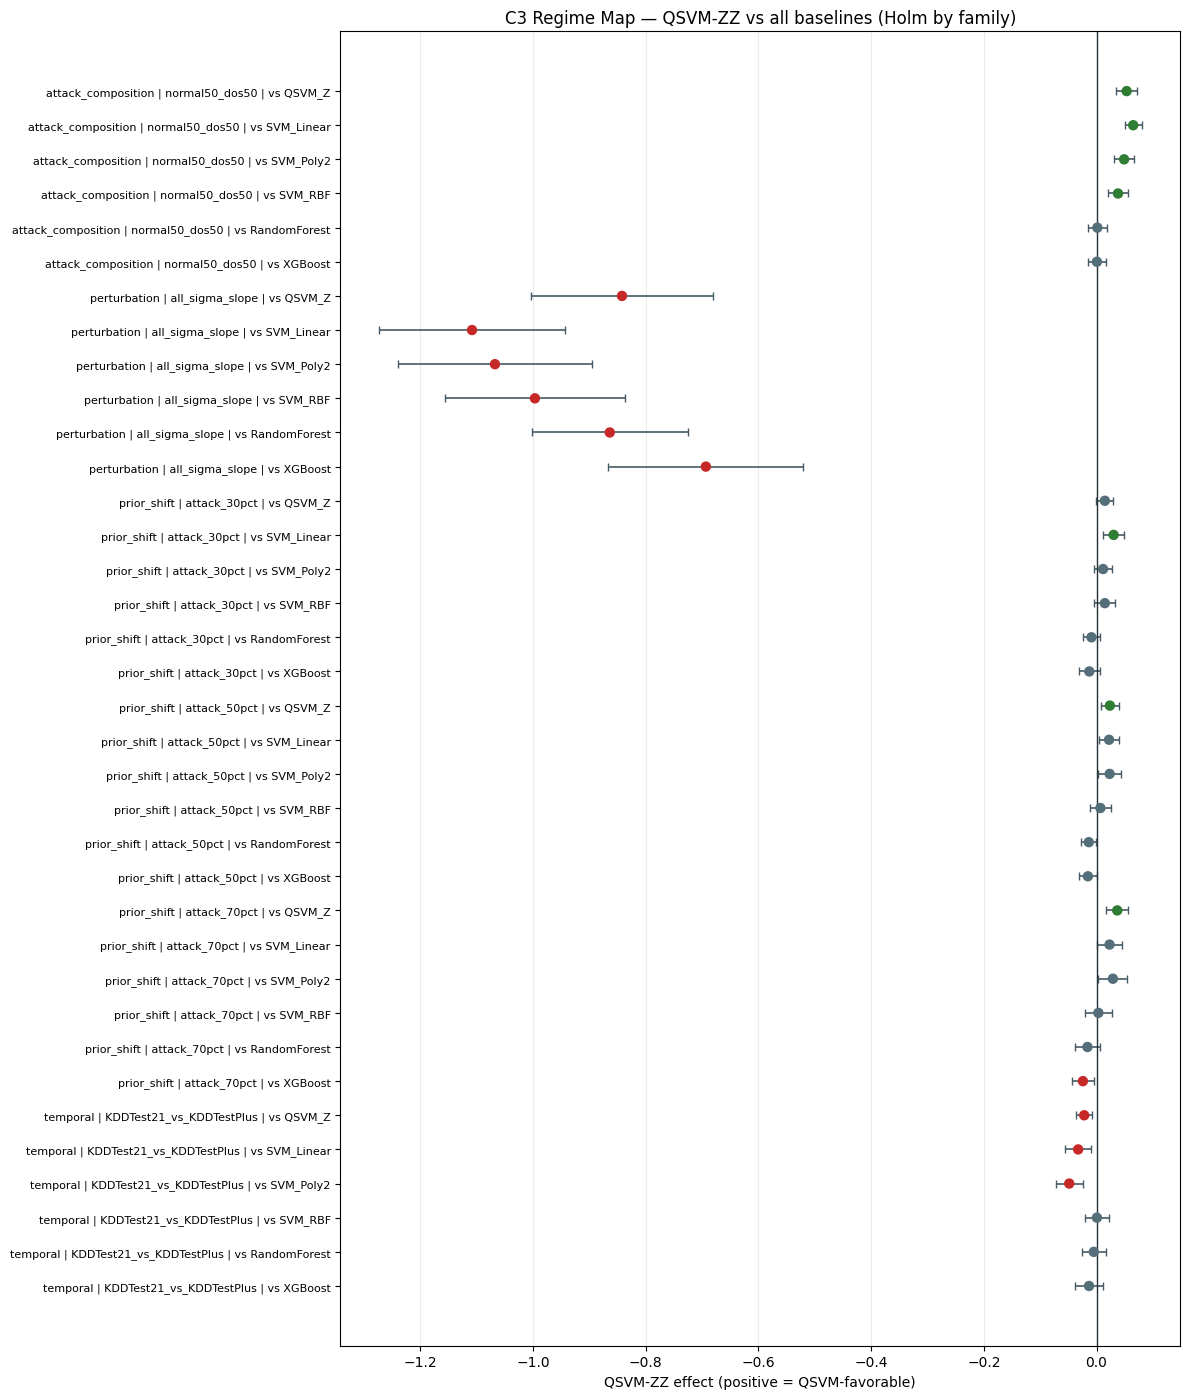

Saved: D:\coding\Research\Quantum\SVM\results\nslkdd\c3_revision\figures\c3_regime_map_main_full_baselines.png


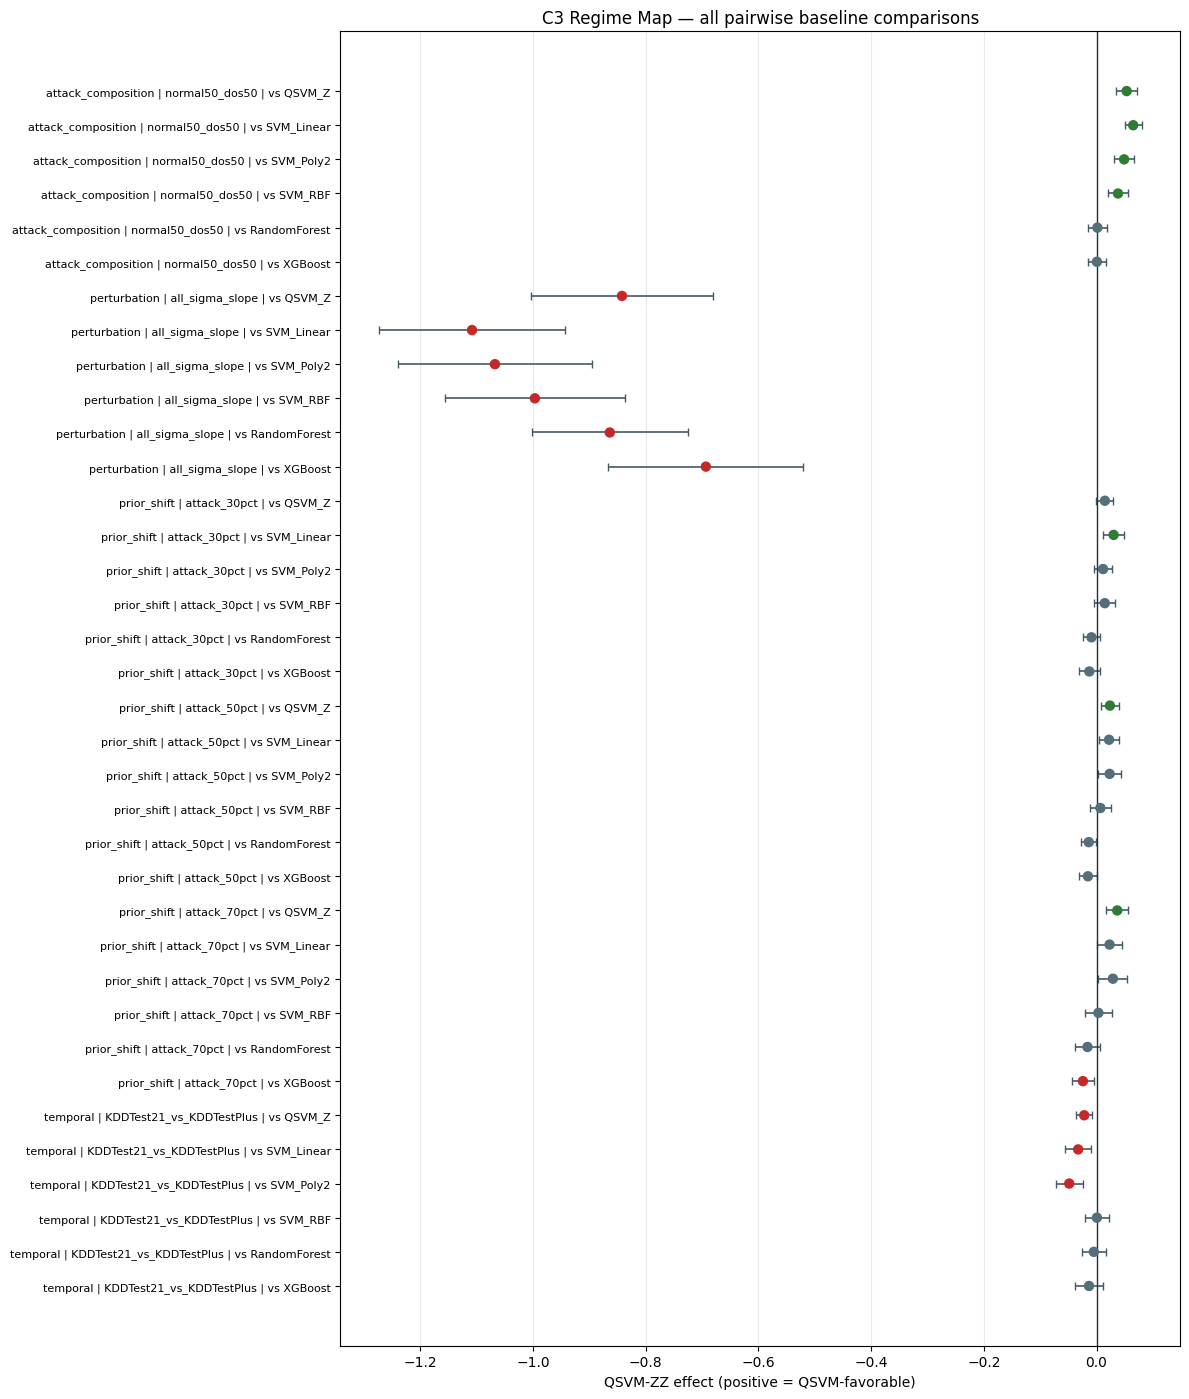

Saved: D:\coding\Research\Quantum\SVM\results\nslkdd\c3_revision\figures\c3_regime_map_supplementary_all_comparators.png


In [13]:
def plot_regime_map(plot_df, output_path, title):
    """Vẽ regime map với CI 95%."""
    if plot_df.empty:
        print(f"No rows for {title}.")
        return
    plot_df = plot_df.copy()
    plot_df["label"] = plot_df["regime"] + " | " + plot_df["condition"] + " | vs " + plot_df["comparison_baseline"]
    plot_df["baseline_order"] = plot_df["comparison_baseline"].map({model: idx for idx, model in enumerate(BASELINES)})
    plot_df = plot_df.sort_values(["regime", "condition", "baseline_order"]).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(plot_df) + 1.5)))
    y = np.arange(len(plot_df))
    colors = plot_df["verdict"].map({
        "QSVM-favorable": "#2E7D32",
        "classical-favorable": "#C62828",
        "inconclusive": "#546E7A",
    }).fillna("#546E7A")
    xerr = np.vstack([
        (plot_df["mean_delta"] - plot_df["ci_low"]).fillna(0).to_numpy(),
        (plot_df["ci_high"] - plot_df["mean_delta"]).fillna(0).to_numpy(),
    ])
    ax.errorbar(plot_df["mean_delta"], y, xerr=xerr, fmt="none", ecolor="#455A64", elinewidth=1.2, capsize=3, zorder=2)
    ax.scatter(plot_df["mean_delta"], y, c=colors, s=42, zorder=3)
    ax.axvline(0, color="#263238", linewidth=1.0)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["label"], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("QSVM-ZZ effect (positive = QSVM-favorable)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


if not regime_summary_df.empty:
    key_conditions = [
        ("temporal", "KDDTest21_vs_KDDTestPlus"),
        ("perturbation", "all_sigma_slope"),
        ("prior_shift", "attack_30pct"),
        ("prior_shift", "attack_50pct"),
        ("prior_shift", "attack_70pct"),
        ("attack_composition", "normal50_dos50"),
    ]
    key = pd.MultiIndex.from_tuples(key_conditions, names=["regime", "condition"])
    indexed = regime_summary_df.set_index(["regime", "condition"])
    main_df = indexed.loc[indexed.index.intersection(key)].reset_index()
    if main_df.empty:
        main_df = regime_summary_df.copy()

    plot_regime_map(
        main_df,
        FIGURE_DIR / "c3_regime_map_main_full_baselines.png",
        "C3 Regime Map — QSVM-ZZ vs all baselines (Holm by family)",
    )
    plot_regime_map(
        regime_summary_df,
        FIGURE_DIR / "c3_regime_map_supplementary_all_comparators.png",
        "C3 Regime Map — all pairwise baseline comparisons",
    )
else:
    print("No regime summary available yet.")


## 12. Audit and export artifacts


In [14]:
def file_exists_nonempty(path):
    """Kiểm tra file tồn tại và không rỗng."""
    path = Path(path)
    return path.exists() and path.stat().st_size > 0


def to_jsonable(value):
    """Ép numpy/pandas/path scalars về kiểu JSON-native trước khi ghi audit."""
    if isinstance(value, dict):
        return {str(k): to_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [to_jsonable(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return value.item()
    if pd.isna(value) and not isinstance(value, (str, bytes, list, tuple, dict)):
        return None
    return value


result_tables = [
    df for df in [temporal_df, perturbation_df, prior_shift_df, attack_composition_df]
    if df is not None and not df.empty
]
all_results_df = pd.concat(result_tables, ignore_index=True) if result_tables else pd.DataFrame()

expected_manifest_counts = {
    "temporal": 2,
    "perturbation": C3_CONFIG["n_runs"] * len(C3_CONFIG["sigma_levels"]),
    "prior_shift": C3_CONFIG["n_runs"] * len(C3_CONFIG["prior_attack_fractions"]),
    "attack_composition": C3_CONFIG["n_runs"],
}
observed_manifest_counts = manifest_df["regime"].value_counts().to_dict()
expected_models = list(ALL_MODELS)
observed_models = sorted(all_results_df["model"].unique().tolist()) if not all_results_df.empty else []
expected_model_count = len(expected_models)

expected_result_contexts_full = {
    "temporal": C3_CONFIG["n_runs"] * 2,
    "perturbation": C3_CONFIG["n_runs"] * len(C3_CONFIG["sigma_levels"]),
    "prior_shift": C3_CONFIG["n_runs"] * len(C3_CONFIG["prior_attack_fractions"]),
    "attack_composition": C3_CONFIG["n_runs"],
}
expected_result_rows_full = int(sum(expected_result_contexts_full.values()) * expected_model_count)

if all_results_df.empty:
    observed_result_rows_by_regime = {}
    observed_contexts_by_regime = {}
    synthetic_condition_run_counts_ok = False
    observed_models_match_expected = False
    observed_context_models_match_expected = False
else:
    observed_result_rows_by_regime = all_results_df["regime"].value_counts().to_dict()
    observed_contexts_by_regime = (
        all_results_df.drop_duplicates(["run_id", "regime", "condition"])
        ["regime"].value_counts().to_dict()
    )
    synthetic_condition_run_counts_ok = bool(
        all_results_df[all_results_df["regime"].isin(["perturbation", "prior_shift", "attack_composition"])]
        .drop_duplicates(["regime", "condition", "run_id"])
        .groupby(["regime", "condition"])["run_id"]
        .nunique()
        .eq(C3_CONFIG["n_runs"])
        .all()
    )
    observed_models_match_expected = sorted(observed_models) == sorted(expected_models)
    context_model_sets = all_results_df.groupby(["run_id", "regime", "condition"])["model"].apply(lambda values: set(values))
    observed_context_models_match_expected = bool(context_model_sets.map(lambda values: values == EXPECTED_MODELS).all())

runs_executed_count = len(RUN_IDS_TO_EXECUTE) if PILOT_MODE else C3_CONFIG["n_runs"]
temporal_mcnemar_expected_rows = runs_executed_count * 2 * len(BASELINES)
temporal_mcnemar_complete = bool(
    file_exists_nonempty(OUTPUT_DIR / "c3_temporal_mcnemar.csv")
    and "temporal_mcnemar_df" in globals()
    and len(temporal_mcnemar_df) == temporal_mcnemar_expected_rows
    and required_temporal_pairs_exist
)

full_run_checks = {
    "expected_models_present": observed_models_match_expected,
    "every_context_has_7_expected_models": observed_context_models_match_expected,
    "result_rows_full_expected": len(all_results_df) == expected_result_rows_full,
    "temporal_full_contexts": observed_contexts_by_regime.get("temporal", 0) == expected_result_contexts_full["temporal"],
    "perturbation_full_contexts": observed_contexts_by_regime.get("perturbation", 0) == expected_result_contexts_full["perturbation"],
    "prior_full_contexts": observed_contexts_by_regime.get("prior_shift", 0) == expected_result_contexts_full["prior_shift"],
    "attack_composition_full_contexts": observed_contexts_by_regime.get("attack_composition", 0) == expected_result_contexts_full["attack_composition"],
    "synthetic_conditions_have_10_runs": synthetic_condition_run_counts_ok,
    "temporal_mcnemar_full": bool(
        "temporal_mcnemar_df" in globals()
        and len(temporal_mcnemar_df) == C3_CONFIG["n_runs"] * 2 * len(BASELINES)
        and required_temporal_pairs_exist
    ),
}

checks = {
    "c1_artifacts_loaded": all(Path(path).exists() for path in C1_ARTIFACT_PATHS.values()),
    "c1_artifact_hashes_in_signature": C3_CONFIG["c1_artifact_hashes"] == C1_ARTIFACT_HASHES,
    "frozen_c1_transform_only": C3_CONFIG["preprocessing_protocol"] == "frozen_C1_SelectKBest_PCA4_MinMaxPi_transform_only",
    "c2_hp_loaded": file_exists_nonempty(C3_CONFIG["c2_contract_path"]),
    "using_chosen_params_only": FROZEN_HYPERPARAMETERS == {model: payload["chosen_params"] for model, payload in hp["models"].items()},
    "qsvm_kernel_params_from_c2_artifact": bool(
        FROZEN_HYPERPARAMETERS["QSVM_ZZ"]["feature_map"] == "ZZFeatureMap"
        and FROZEN_HYPERPARAMETERS["QSVM_ZZ"]["reps"] == C3_CONFIG["reps"]
        and FROZEN_HYPERPARAMETERS["QSVM_ZZ"]["entanglement"] == C3_CONFIG["entanglement"]
        and FROZEN_HYPERPARAMETERS["QSVM_Z"]["feature_map"] == "ZFeatureMap"
        and FROZEN_HYPERPARAMETERS["QSVM_Z"]["reps"] == C3_CONFIG["reps"]
    ),
    "full_7_model_contract": set(C3_CONFIG["all_models"]) == EXPECTED_MODELS and len(C3_CONFIG["all_models"]) == 7,
    "inferential_families_complete": set(BASELINE_FAMILY_BY_MODEL) == set(BASELINES),
    "holm_family_policy_present": bool(
        file_exists_nonempty(OUTPUT_DIR / "c3_pairwise_statistics.csv")
        and ("holm_p" in regime_summary_df.columns if not regime_summary_df.empty else True)
        and ("baseline_family" in regime_summary_df.columns if not regime_summary_df.empty else True)
    ),
    "temporal_mcnemar_complete": temporal_mcnemar_complete,
    "expected_models_present": observed_models_match_expected,
    "every_context_has_7_expected_models": observed_context_models_match_expected,
    "10_training_runs": len(train_runs) == 10,
    "train_size_1000": all(len(df) == 1000 for df in train_runs.values()),
    "eval_size_1000": bool((manifest_df["n_samples"] == 1000).all()),
    "manifest_expected_counts": all(observed_manifest_counts.get(k, 0) == v for k, v in expected_manifest_counts.items()),
    "no_c3_tuning": True,
    "temporal_sets_fixed": manifest_df[manifest_df["regime"] == "temporal"]["run_id"].isna().all(),
    "perturbation_matched": manifest_df[manifest_df["regime"] == "perturbation"].groupby("run_id")["condition"].nunique().eq(len(C3_CONFIG["sigma_levels"])).all(),
    "prior_targets_exact": all(
        np.allclose(
            manifest_df[(manifest_df["regime"] == "prior_shift") & (manifest_df["condition"] == condition)]["attack_fraction"],
            expected_fraction,
        )
        for condition, expected_fraction in expected_prior.items()
    ),
    "10_prior_runs_each": manifest_df[manifest_df["regime"] == "prior_shift"].groupby("condition")["run_id"].nunique().eq(10).all(),
    "10_perturbation_runs": manifest_df[manifest_df["regime"] == "perturbation"]["run_id"].nunique() == 10,
    "all_models_share_eval_subset": bool(
        not all_results_df.empty
        and all_results_df.groupby(["run_id", "regime", "condition"])["subset_path"].nunique().eq(1).all()
    ),
    "statistics_complete": bool(
        file_exists_nonempty(OUTPUT_DIR / "c3_pairwise_statistics.csv")
        and file_exists_nonempty(OUTPUT_DIR / "c3_temporal_mcnemar.csv")
    ),
    "full_run_audit_complete": True if PILOT_MODE else all(full_run_checks.values()),
}

pilot_core_checks = [
    checks["c1_artifacts_loaded"],
    checks["c1_artifact_hashes_in_signature"],
    checks["frozen_c1_transform_only"],
    checks["c2_hp_loaded"],
    checks["using_chosen_params_only"],
    checks["qsvm_kernel_params_from_c2_artifact"],
    checks["full_7_model_contract"],
    checks["inferential_families_complete"],
    checks["temporal_mcnemar_complete"],
    checks["expected_models_present"],
    checks["every_context_has_7_expected_models"],
    checks["10_training_runs"],
    checks["train_size_1000"],
    checks["eval_size_1000"],
    checks["manifest_expected_counts"],
    checks["no_c3_tuning"],
]
status = "PILOT_PASS" if PILOT_MODE and all(pilot_core_checks) else "PASS" if all(checks.values()) else "FAIL"

summary = {
    "status": status,
    "pilot_mode": PILOT_MODE,
    "config": C3_CONFIG,
    "checks": checks,
    "full_run_expected": {
        "expected_models": expected_models,
        "expected_model_count": expected_model_count,
        "expected_contexts": expected_result_contexts_full,
        "expected_result_rows": expected_result_rows_full,
        "observed_models": observed_models,
        "observed_contexts_by_regime": observed_contexts_by_regime,
        "observed_result_rows_by_regime": observed_result_rows_by_regime,
        "temporal_mcnemar_expected_rows": temporal_mcnemar_expected_rows,
        "temporal_mcnemar_observed_rows": int(len(temporal_mcnemar_df)) if "temporal_mcnemar_df" in globals() else 0,
        "checks": full_run_checks,
    },
    "artifacts": {
        "config": str(OUTPUT_DIR / "c3_config.json"),
        "frozen_hyperparameters": str(OUTPUT_DIR / "c3_frozen_hyperparameters.json"),
        "manifest": str(OUTPUT_DIR / "c3_eval_manifest.csv"),
        "temporal_per_run": str(OUTPUT_DIR / "c3_temporal_per_run.csv"),
        "perturbation_per_run": str(OUTPUT_DIR / "c3_perturbation_per_run.csv"),
        "prior_shift_per_run": str(OUTPUT_DIR / "c3_prior_shift_per_run.csv"),
        "attack_composition_per_run": str(OUTPUT_DIR / "c3_attack_composition_per_run.csv"),
        "pairwise_statistics": str(OUTPUT_DIR / "c3_pairwise_statistics.csv"),
        "regime_summary": str(OUTPUT_DIR / "c3_regime_summary.csv"),
        "temporal_mcnemar": str(OUTPUT_DIR / "c3_temporal_mcnemar.csv"),
        "regime_map_main": str(FIGURE_DIR / "c3_regime_map_main_full_baselines.png"),
        "regime_map_supplementary": str(FIGURE_DIR / "c3_regime_map_supplementary_all_comparators.png"),
    },
}

summary = to_jsonable(summary)
checks = summary["checks"]

with open(OUTPUT_DIR / "c3_summary.json", "w", encoding="utf-8") as fp:
    json.dump(summary, fp, indent=2, ensure_ascii=False, allow_nan=False)

print(json.dumps(checks, indent=2, ensure_ascii=False, allow_nan=False))
print()
print(json.dumps(summary["full_run_expected"], indent=2, ensure_ascii=False, allow_nan=False))
print()
print(f"C3 REVISION STATUS: {status}")
if status == "PILOT_PASS":
    print("Pilot pass. Đổi PILOT_MODE=False ở Section 1 để chạy full 10-run C3.")
print(f"Saved: {OUTPUT_DIR / 'c3_summary.json'}")


{
  "c1_artifacts_loaded": true,
  "c1_artifact_hashes_in_signature": true,
  "frozen_c1_transform_only": true,
  "c2_hp_loaded": true,
  "using_chosen_params_only": true,
  "qsvm_kernel_params_from_c2_artifact": true,
  "full_7_model_contract": true,
  "inferential_families_complete": true,
  "holm_family_policy_present": true,
  "temporal_mcnemar_complete": true,
  "expected_models_present": true,
  "every_context_has_7_expected_models": true,
  "10_training_runs": true,
  "train_size_1000": true,
  "eval_size_1000": true,
  "manifest_expected_counts": true,
  "no_c3_tuning": true,
  "temporal_sets_fixed": true,
  "perturbation_matched": true,
  "prior_targets_exact": true,
  "10_prior_runs_each": true,
  "10_perturbation_runs": true,
  "all_models_share_eval_subset": true,
  "statistics_complete": true,
  "full_run_audit_complete": true
}

{
  "expected_models": [
    "QSVM_ZZ",
    "QSVM_Z",
    "SVM_Linear",
    "SVM_Poly2",
    "SVM_RBF",
    "RandomForest",
    "XGBoost"
  ],
  